<a href="https://colab.research.google.com/github/JoseDuarteCastro1496-prog/JoseDuarteCastro1496-prog/blob/main/Analisis_Diabetes_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto del dataset
Estos datos buscan entrenar un modelo de machine learning, el cual buscaria determinar patrones que indiquen si una persona puede tener o no diabetes. Por ejemplo: Indice de masa corporal alto más edad avanzada provocarían diabetes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Análisis exploratorio

In [ ]:
print(f"Forma del dataset: Cantidad de filas y columnas{df.shape}")
print("--"*30)
print(f"Cantidad de datos nulos por columna:\n{df.isna().sum()}")
print("--"*30)
cantidad_duplicados = df.duplicated().sum()
print(f"Cantidad de datos duplicados: {cantidad_duplicados}")

Forma del dataset: Cantidad de filas y columnas(768, 9)
------------------------------------------------------------
Cantidad de datos nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
------------------------------------------------------------
Cantidad de datos duplicados: 0


In [ ]:
print(df.info())
print("--"*30)
print(f"{df.describe()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
------------------------------------------------------------
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  12

# Analisis univariado

/tmp/ipython-input-58949317.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pregnancies', data=df, palette='viridis')


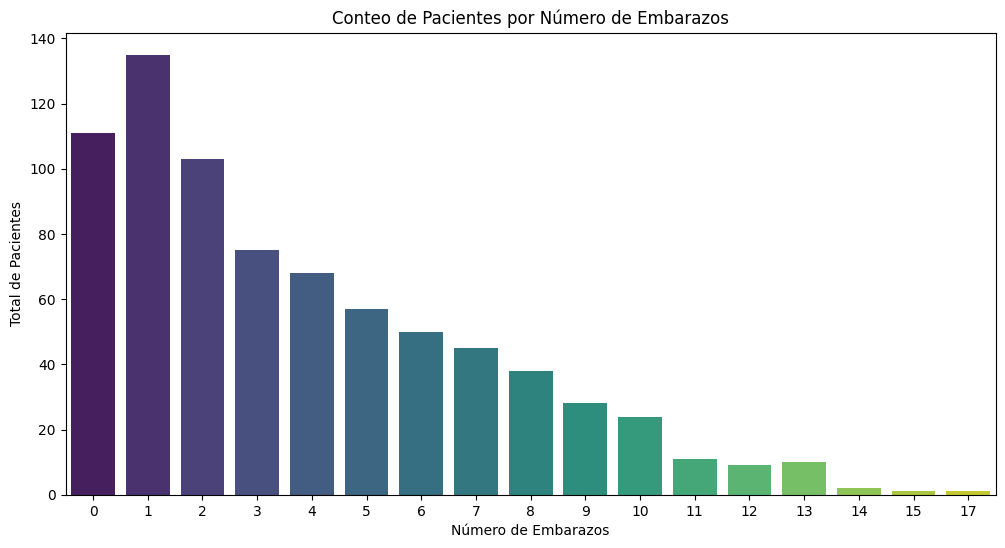

In [ ]:

plt.figure(figsize=(12,6))
# El countplot trata cada número como una categoría separada automáticamente
sns.countplot(x='Pregnancies', data=df, palette='viridis')

plt.title('Conteo de Pacientes por Número de Embarazos')
plt.xlabel('Número de Embarazos')
plt.ylabel('Total de Pacientes')
plt.show()


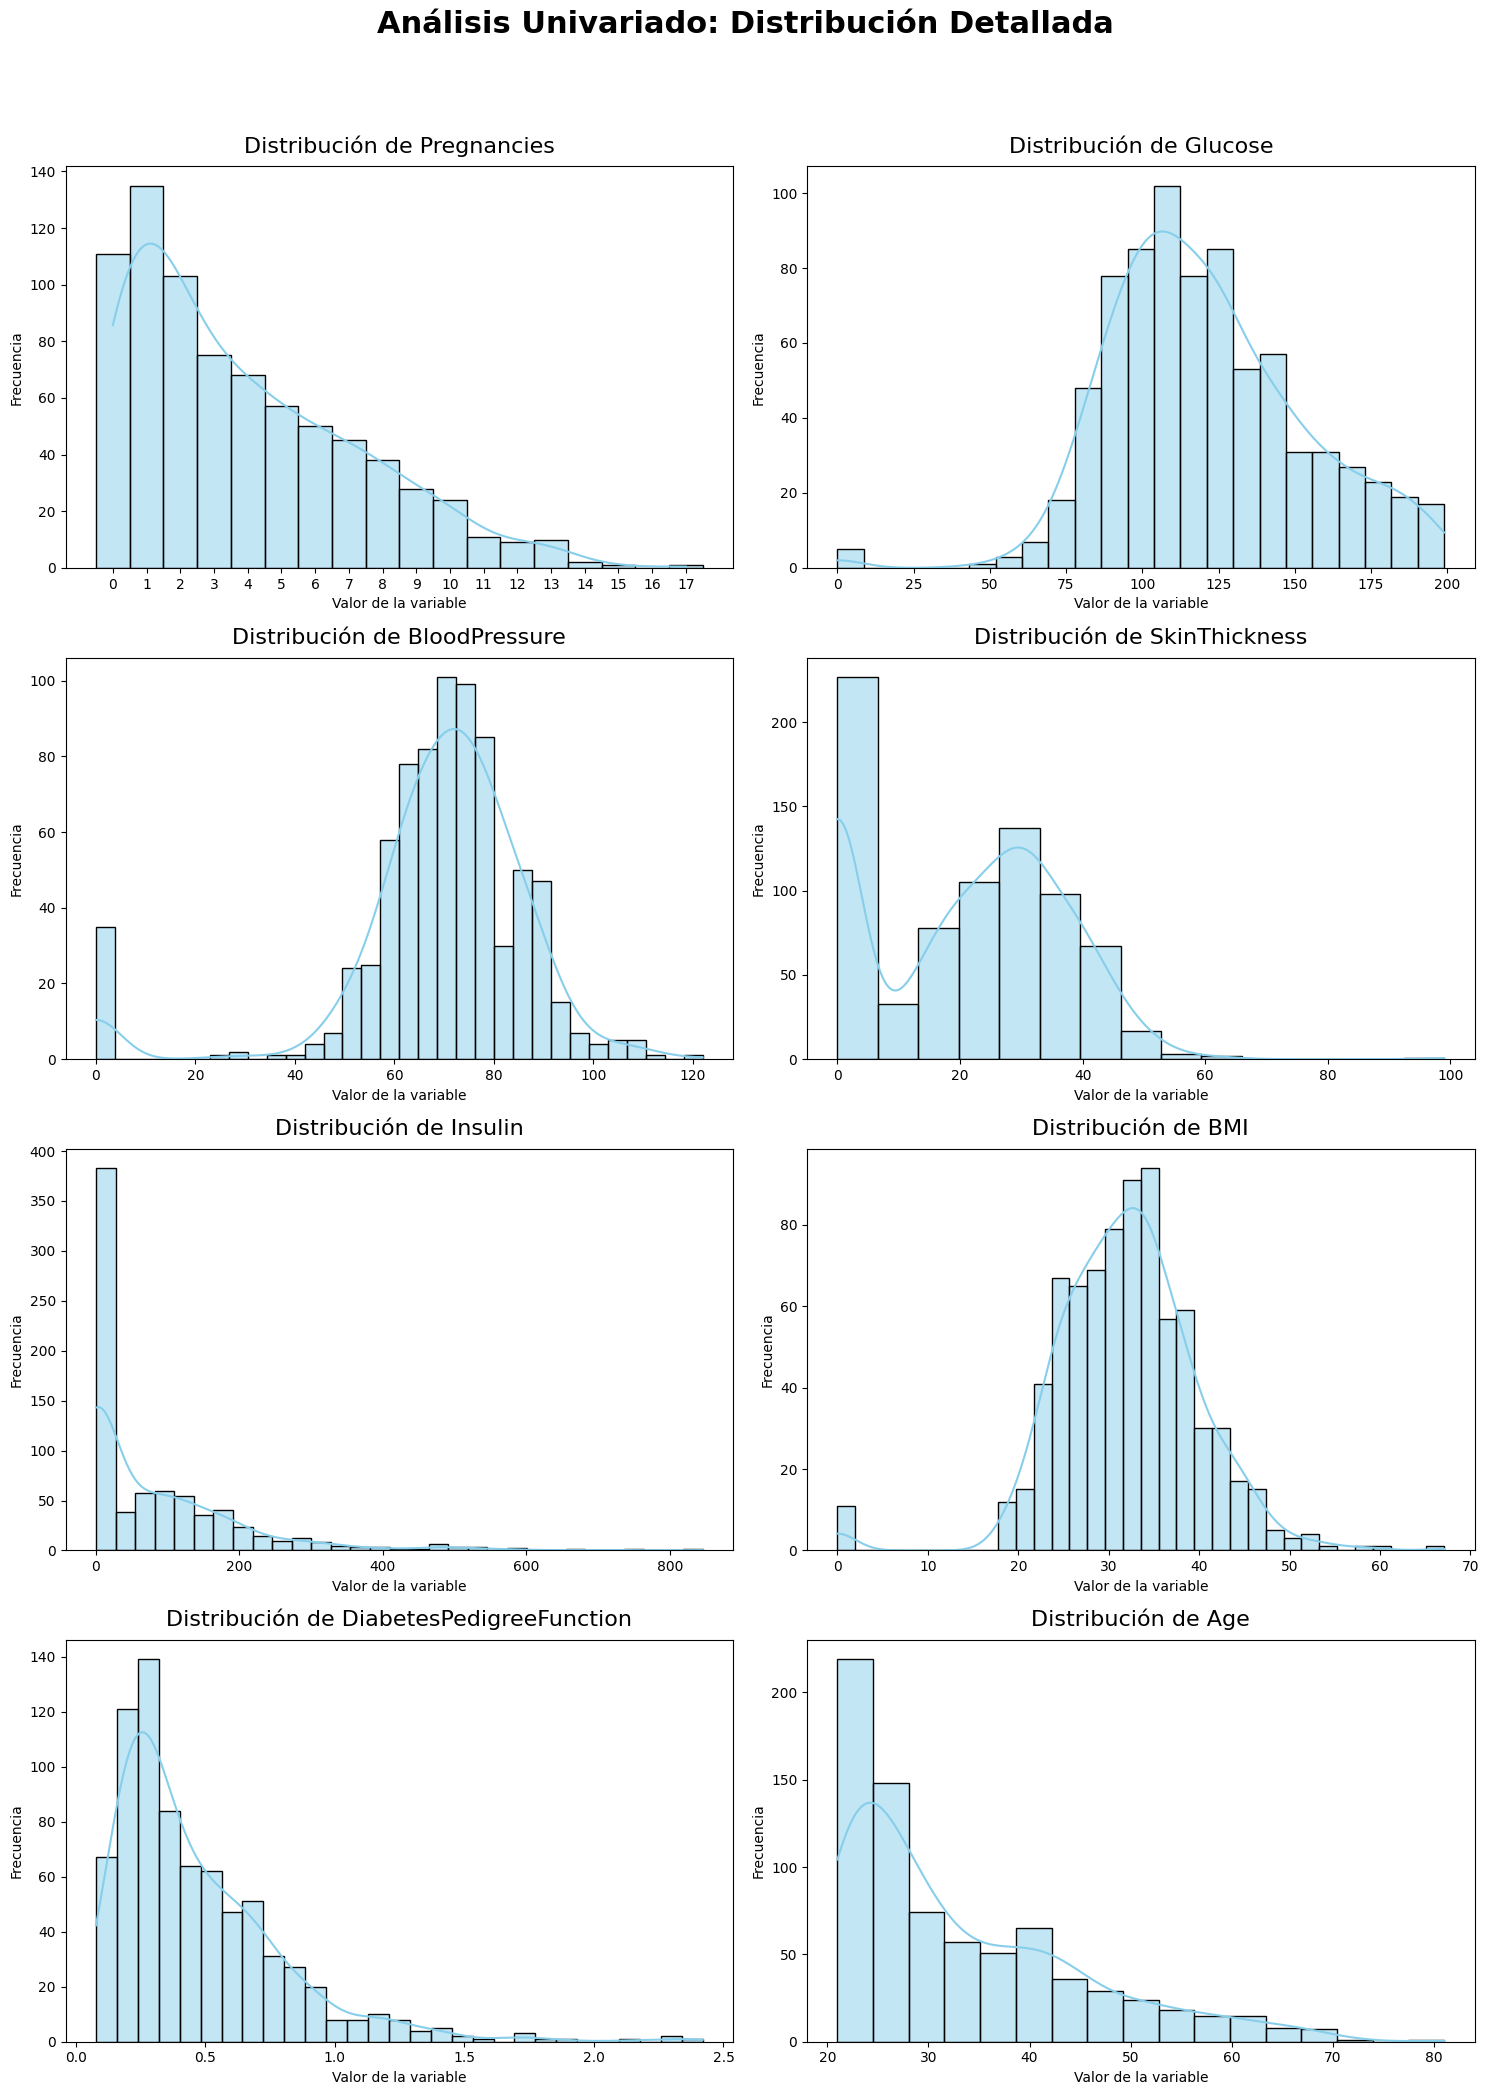

In [ ]:


cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

# Configuramos la rejilla
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 22))
fig.suptitle('Análisis Univariado: Distribución Detallada', fontsize=22, fontweight='bold')

for i, col in enumerate(cols):
    row = i // 2
    column = i % 2
    ax = axes[row, column]

    # Lógica para centrar barras en Pregnancies (como en tus fotos exitosas)
    if col == 'Pregnancies':
        sns.histplot(df[col], kde=True, discrete=True, ax=ax, color='skyblue', edgecolor='black')
        ax.set_xticks(range(int(df[col].min()), int(df[col].max()) + 1))
    else:
        # Histograma estándar para variables continuas (Glucosa, BMI, etc.)
        sns.histplot(df[col], kde=True, ax=ax, color='skyblue', edgecolor='black')

    ax.set_title(f'Distribución de {col}', fontsize=16, pad=10)
    ax.set_xlabel('Valor de la variable')
    ax.set_ylabel('Frecuencia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Ajustar valores:
Se deben hacer ajustes en los datos puesto que no existen valores de presión sanguinea de 0 o glucosas menores a 40.

**1-Presión en la sangre**

In [ ]:
import numpy as np

# 1. Marcamos como nulos los valores imposibles (0 y menores a 40)
# Usamos 40 como límite inferior razonable para este estudio
df.loc[df['BloodPressure'] < 40, 'BloodPressure'] = np.nan

# 2. Rellenamos esos nulos con la mediana (el valor central de los sanos)
mediana_presion = df['BloodPressure'].median()
df['BloodPressure'] = df['BloodPressure'].fillna(mediana_presion)

print(f"La presión ha sido ajustada usando la mediana: {mediana_presion}")

La presión ha sido ajustada usando la mediana: 72.0


/tmp/ipython-input-1788699307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='BloodPressure', data=df, palette='viridis')


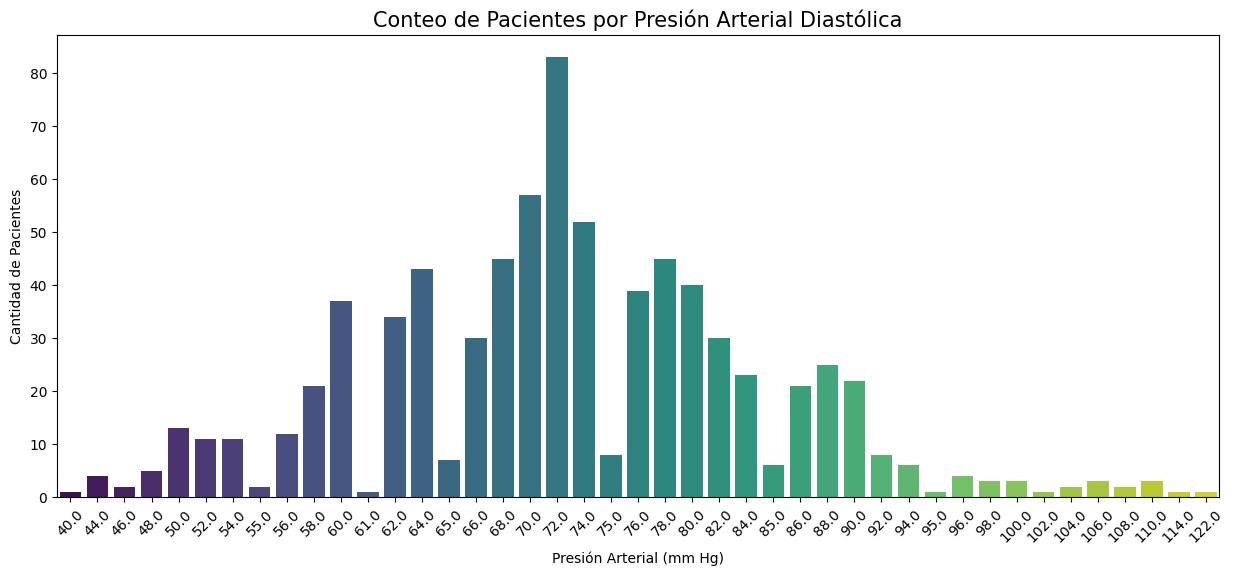

In [ ]:

plt.figure(figsize=(15, 6))

# Usamos countplot para ver cada valor medido de presión
sns.countplot(x='BloodPressure', data=df, palette='viridis')

plt.title('Conteo de Pacientes por Presión Arterial Diastólica', fontsize=15)
plt.xlabel('Presión Arterial (mm Hg)')
plt.ylabel('Cantidad de Pacientes')

# Rotamos las etiquetas del eje X para que se lean bien si hay muchos valores
plt.xticks(rotation=45)

plt.show()

2-Glucosa

In [ ]:

# 1. Identificar y convertir los ceros en valores nulos (NaN)
# En glucosa, cualquier valor < 40 ya es sospechoso en este estudio
df.loc[df['Glucose'] < 40, 'Glucose'] = np.nan

# 2. Calcular la mediana de la glucosa
mediana_glucosa = df['Glucose'].median()

# 3. Rellenar los huecos
df['Glucose'] = df['Glucose'].fillna(mediana_glucosa)

print(f"Glucosa ajustada. Mediana aplicada: {mediana_glucosa}")

Glucosa ajustada. Mediana aplicada: 117.0


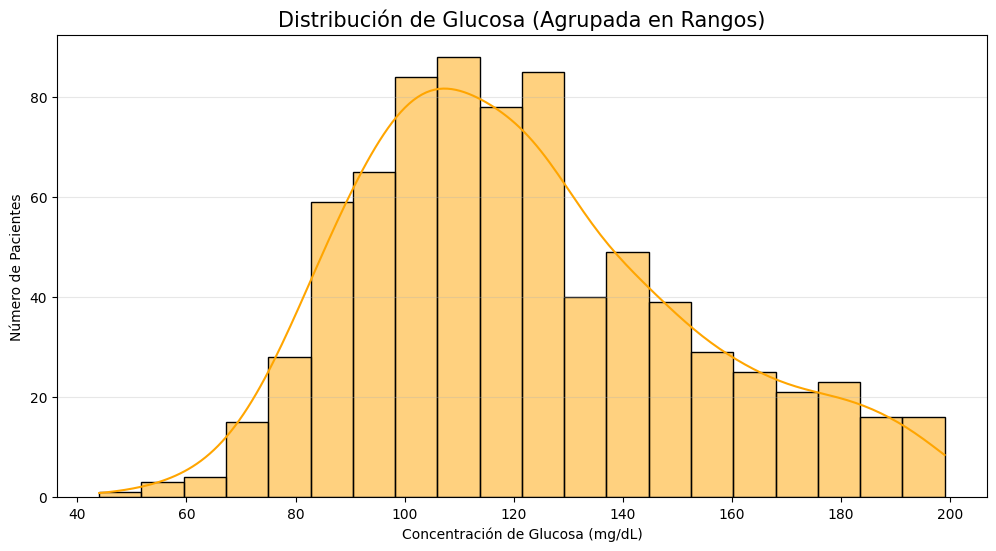

In [ ]:

plt.figure(figsize=(12, 6))

# Usamos histplot en lugar de countplot
# bins=20 agrupa los valores en 20 barras para que sea fácil de leer
sns.histplot(df['Glucose'], bins=20, kde=True, color='orange', edgecolor='black')

plt.title('Distribución de Glucosa (Agrupada en Rangos)', fontsize=15)
plt.xlabel('Concentración de Glucosa (mg/dL)')
plt.ylabel('Número de Pacientes')

# Añadimos una cuadrícula para facilitar la lectura de las alturas
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
import numpy as np

# 1. Lista de columnas a corregir
cols_a_limpiar = ['Insulin', 'SkinThickness', 'BMI']

# 2. Convertimos los 0 en NaN para que no afecten los cálculos
df[cols_a_limpiar] = df[cols_a_limpiar].replace(0, np.nan)

# 3. Imputamos con la mediana
for col in cols_a_limpiar:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)
    print(f"Columna {col} ajustada con la mediana: {mediana}")

# 4. Verificación final de nulos y ceros
print("\nConteo de nulos tras limpieza:")
print(df.isnull().sum())

Columna Insulin ajustada con la mediana: 125.0
Columna SkinThickness ajustada con la mediana: 29.0
Columna BMI ajustada con la mediana: 32.3

Conteo de nulos tras limpieza:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


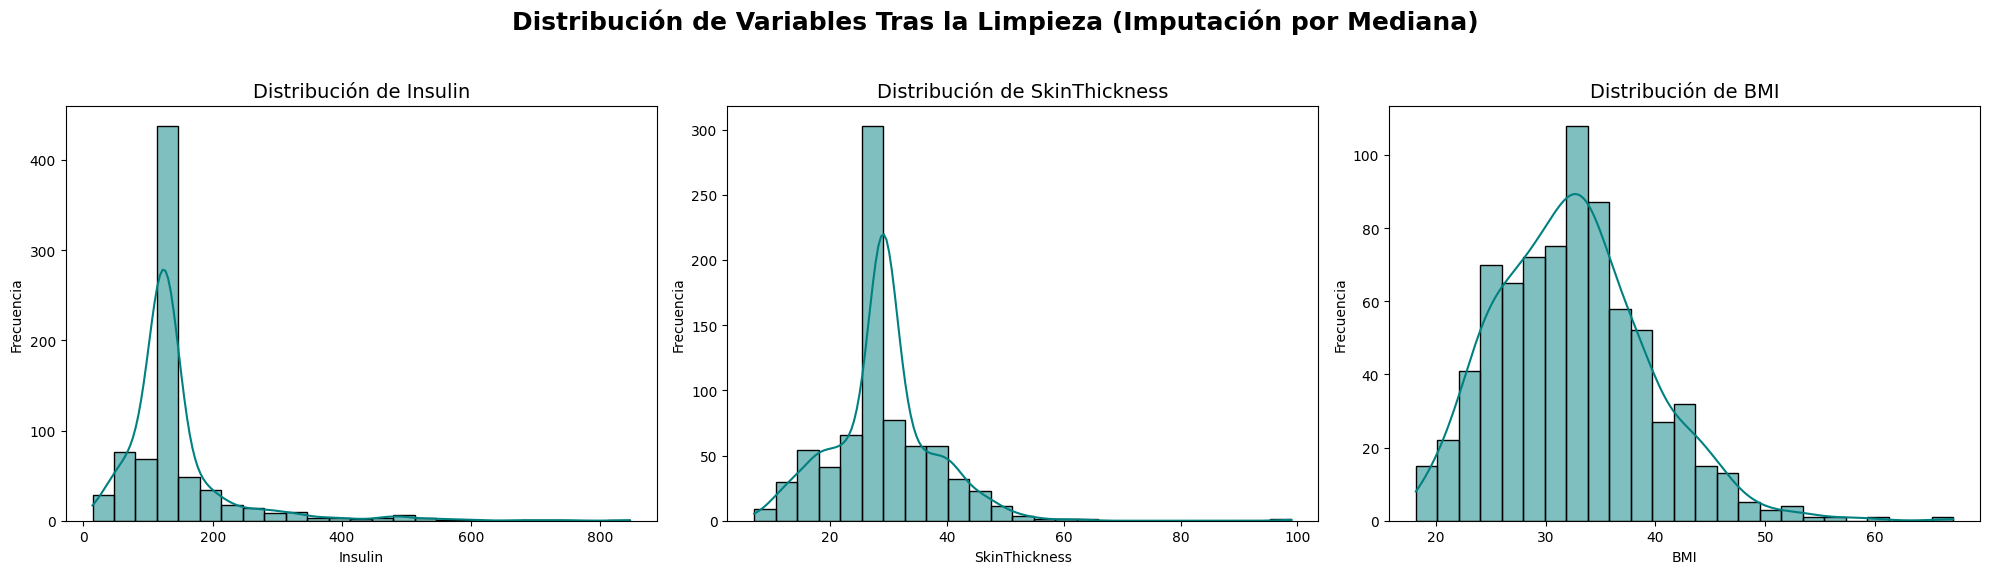

In [ ]:
# Lista de las variables que acabamos de limpiar
cols_ajustadas = ['Insulin', 'SkinThickness', 'BMI']

# Creamos la figura con 1 fila y 3 columnas
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
fig.suptitle('Distribución de Variables Tras la Limpieza (Imputación por Mediana)', fontsize=18, fontweight='bold')

for i, col in enumerate(cols_ajustadas):
    # Graficamos el histograma con curva de densidad (KDE)
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', edgecolor='black', bins=25)

    axes[i].set_title(f'Distribución de {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Matriz de correlación**

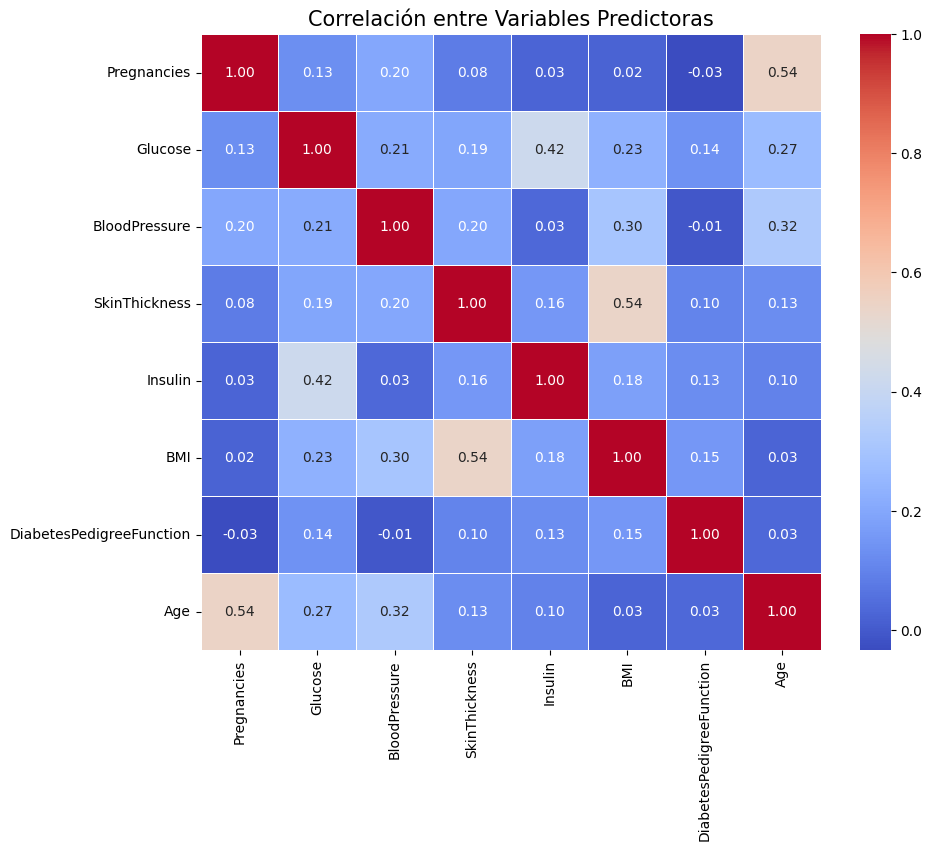

In [ ]:
# 3- Matriz de correlación
# Esto nos permite ver solo cómo se relacionan las características físicas entre sí
df_variables = df.drop('Outcome', axis=1)

# 2. Calculamos la matriz solo para estas variables
corr_matrix_vars = df_variables.corr()

# 3. Graficamos el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_vars, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlación entre Variables Predictoras', fontsize=15)
plt.show()

# ENTRENAMIENTO DEL MODELO

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definimos X (variables predictoras) y y (lo que queremos predecir)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Escalamos los datos (esto ayuda a que el modelo no dé más peso a números grandes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos listos: 80% entrenamiento, 20% prueba.")

Datos listos: 80% entrenamiento, 20% prueba.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Creamos y entrenamos el modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)

# Hacemos predicciones con el grupo de prueba
y_pred = modelo.predict(X_test_scaled)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


/tmp/ipython-input-4243555031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=importancias.index, palette='viridis')


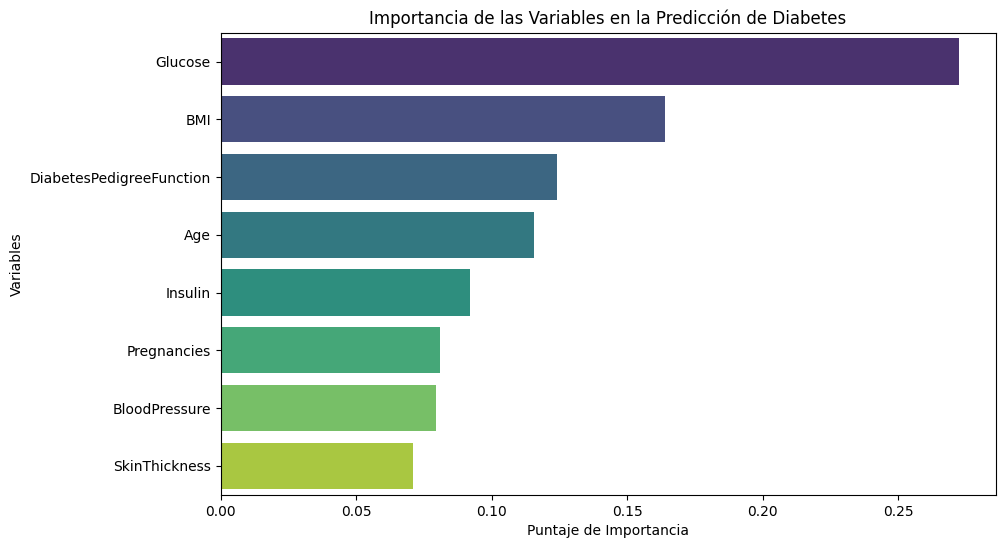

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos la importancia
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

# Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=importancias.index, palette='viridis')
plt.title('Importancia de las Variables en la Predicción de Diabetes')
plt.xlabel('Puntaje de Importancia')
plt.ylabel('Variables')
plt.show()

<Figure size 800x600 with 0 Axes>

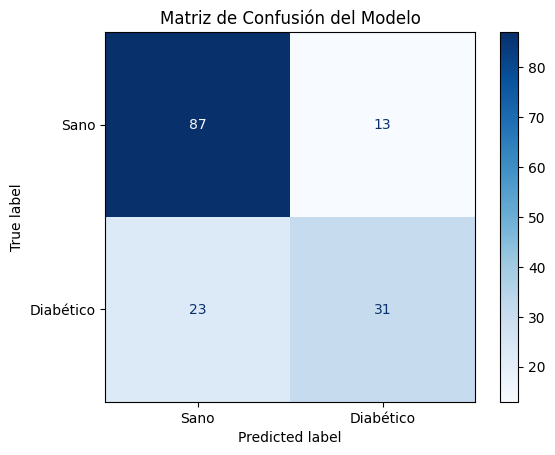

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generamos la matriz
cm = confusion_matrix(y_test, y_pred)

# La graficamos de forma bonita
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Diabético'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión del Modelo')
plt.show()

Analiss con salidad de diagnostico


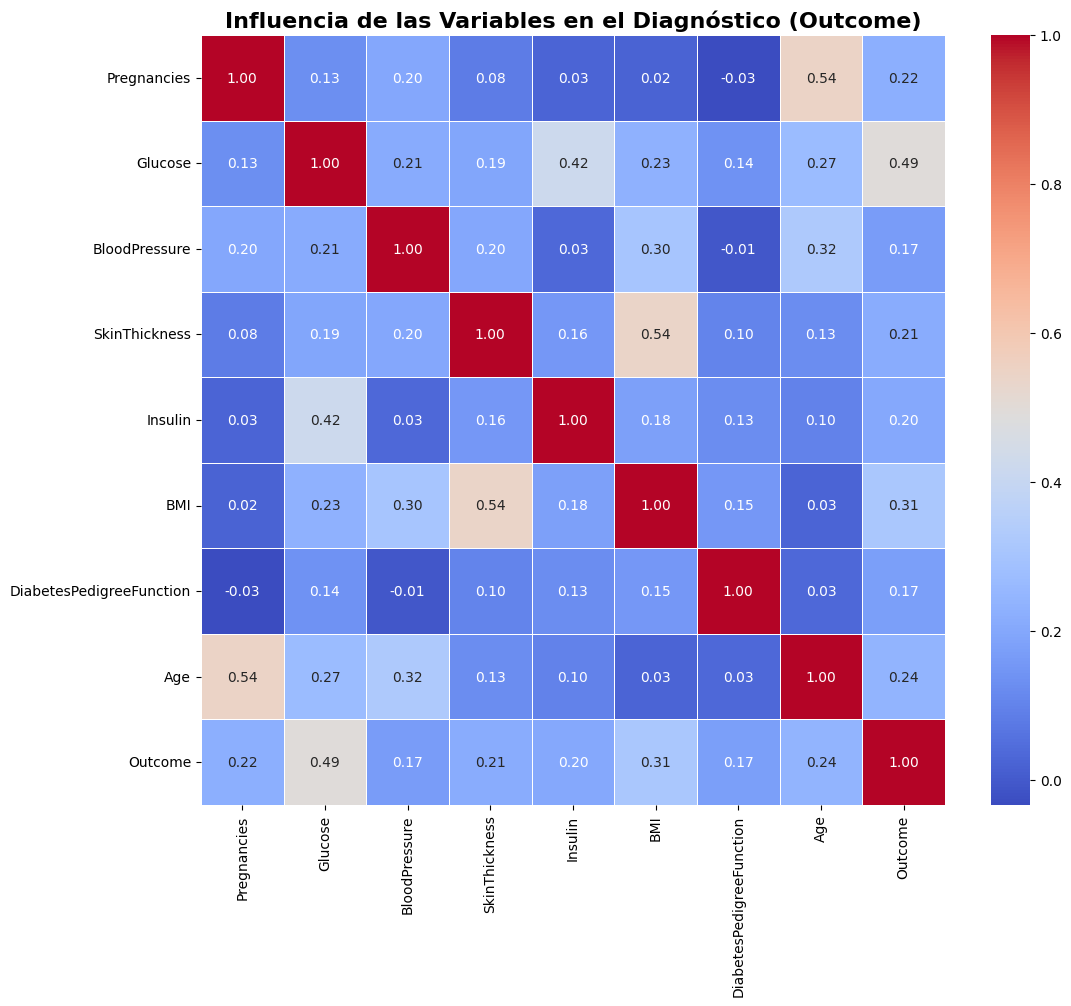

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la correlación de TODO el DataFrame
# Ahora incluimos el Outcome para ver quién manda en el diagnóstico
full_corr = df.corr()

# 2. Configuramos el mapa de calor
plt.figure(figsize=(12, 10))

# Usamos 'coolwarm' para que los rojos (correlación positiva) resalten más
sns.heatmap(full_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Influencia de las Variables en el Diagnóstico (Outcome)', fontsize=16, fontweight='bold')
plt.show()

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



<Figure size 800x600 with 0 Axes>

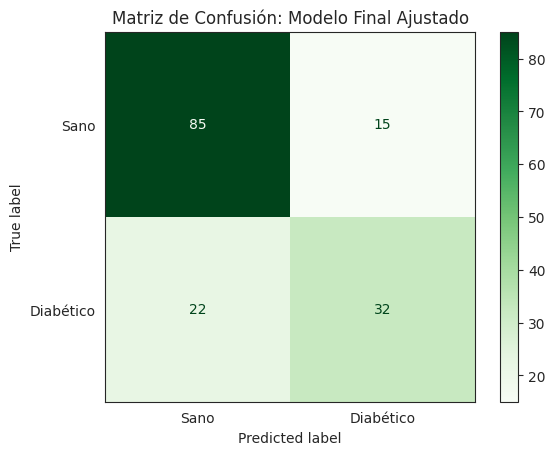

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Preparación final de los datos
# Aseguramos que X contenga todas las variables y y sea el Outcome
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividimos en entrenamiento (80%) y prueba (20%)
# Usamos 'stratify' para que la proporción de diabéticos sea igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. Escalado de variables
# Esto es vital para que variables con números grandes (como Insulin)
# no dominen injustamente sobre otras como BMI
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entrenamiento del Modelo
# Configuramos el modelo con 100 árboles
modelo_final = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
modelo_final.fit(X_train_scaled, y_train)

# 4. Evaluación de resultados
y_pred = modelo_final.predict(X_test_scaled)

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# 5. Matriz de Confusión Visual
plt.figure(figsize=(8, 6))
sns.set_style("white")
ConfusionMatrixDisplay.from_estimator(modelo_final, X_test_scaled, y_test,
                                      display_labels=['Sano', 'Diabético'],
                                      cmap='Greens')
plt.title('Matriz de Confusión: Modelo Final Ajustado')
plt.show()

## Probar el modelo con un nuevo paciente para determinar si lo diagnostica correctamente

In [ ]:
# Definimos los datos de una nueva paciente
# Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age
nueva_paciente = np.array([[2, 150, 70, 25, 120, 30.5, 0.5, 35]])

# Escalamos los datos con el mismo scaler que usamos para el modelo
nueva_paciente_scaled = scaler.transform(nueva_paciente)

# Realizamos la predicción
prediccion = modelo_final.predict(nueva_paciente_scaled)
probabilidad = modelo_final.predict_proba(nueva_paciente_scaled)

if prediccion[0] == 1:
    print(f"Resultado: Positivo para Diabetes con una probabilidad del {probabilidad[0][1]*100:.2f}%")
else:
    print(f"Resultado: Negativo para Diabetes con una probabilidad del {probabilidad[0][0]*100:.2f}%")

Resultado: Positivo para Diabetes con una probabilidad del 55.13%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

# Guardamos el modelo
joblib.dump(modelo_final, 'modelo_diabetes.pkl')

# Guardamos el escalador (¡MUY IMPORTANTE!)
joblib.dump(scaler, 'escalador_diabetes.pkl')

print("Modelo y escalador guardados con éxito.")

from google.colab import files
files.download('modelo_diabetes.pkl')
files.download('escalador_diabetes.pkl')

Modelo y escalador guardados con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>